In [1]:
import pandas as pd
import numpy as np

df_path="/kaggle/input/datasets/boladmamadou/defautpaiements/dataset_credit_senegal.csv"

df= pd.read_csv(df_path)

df.head()

,age,genre,region,zone_urbaine,profession_type,profession_detail,revenu_mensuel,anciennete_emploi,montant_credit,duree_credit,historique_credit_mois,defaut_anterieur,mobile_money,garantie,education,situation_matrimoniale,personnes_charge,defaut_paiement
0,40,M,Thiès,0,Fonctionnaire,Douanes,389272,15,4885984,12,31,0,0,Salaire,Secondaire,Marié(e),3,1
1,33,M,Dakar,1,Commerçant,Cosmétiques,341025,11,1672093,48,31,1,1,Stock,Primaire,Marié(e),3,1
2,42,M,Kédougou,1,Commerçant,Vêtements,241910,8,2801781,6,45,0,1,Caution,Secondaire,Marié(e),1,1
3,53,M,Saint-Louis,0,Commerçant,Transport,685896,25,8942996,18,12,0,1,Stock,Supérieur,Célibataire,3,0
4,32,M,Saint-Louis,0,Commerçant,Commerce général,602630,11,10883587,6,34,0,1,Immobilier,Secondaire,Marié(e),4,0


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   age                     5000 non-null   int64 
 1   genre                   5000 non-null   object
 2   region                  5000 non-null   object
 3   zone_urbaine            5000 non-null   int64 
 4   profession_type         5000 non-null   object
 5   profession_detail       5000 non-null   object
 6   revenu_mensuel          5000 non-null   int64 
 7   anciennete_emploi       5000 non-null   int64 
 8   montant_credit          5000 non-null   int64 
 9   duree_credit            5000 non-null   int64 
 10  historique_credit_mois  5000 non-null   int64 
 11  defaut_anterieur        5000 non-null   int64 
 12  mobile_money            5000 non-null   int64 
 13  garantie                5000 non-null   object
 14  education               5000 non-null   object
 15  situ

,age,zone_urbaine,revenu_mensuel,anciennete_emploi,montant_credit,duree_credit,historique_credit_mois,defaut_anterieur,mobile_money,personnes_charge,defaut_paiement
count,5000.000000,5000.000000,5.000000e+03,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,35.011000,0.718200,5.984960e+05,12.368600,6.175850e+06,20.136000,20.765200,0.082600,0.859000,2.447200,0.236800
std,11.015568,0.449921,4.145043e+05,10.145626,5.710855e+06,11.212718,22.825439,0.275304,0.348056,1.544438,0.425161
min,18.000000,0.000000,5.000000e+04,0.000000,1.710830e+05,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,0.000000,3.429722e+05,3.000000,2.603853e+06,12.000000,4.000000,0.000000,1.000000,1.000000,0.000000
50%,35.000000,1.000000,4.961475e+05,11.000000,4.624349e+06,18.000000,13.000000,0.000000,1.000000,2.000000,0.000000
75%,42.000000,1.000000,7.147040e+05,19.000000,7.561140e+06,24.000000,30.000000,0.000000,1.000000,3.000000,0.000000
max,65.000000,1.000000,4.206453e+06,44.000000,6.468545e+07,48.000000,193.000000,1.000000,1.000000,10.000000,1.000000


In [2]:
df.isnull().sum()

age                       0
genre                     0
region                    0
zone_urbaine              0
profession_type           0
profession_detail         0
revenu_mensuel            0
anciennete_emploi         0
montant_credit            0
duree_credit              0
historique_credit_mois    0
defaut_anterieur          0
mobile_money              0
garantie                  0
education                 0
situation_matrimoniale    0
personnes_charge          0
defaut_paiement           0
dtype: int64

**DISTRIBUTION DE LA VARIABLE CIBLE**

/tmp/ipykernel_57/1956244456.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='defaut_paiement', palette='Set2')


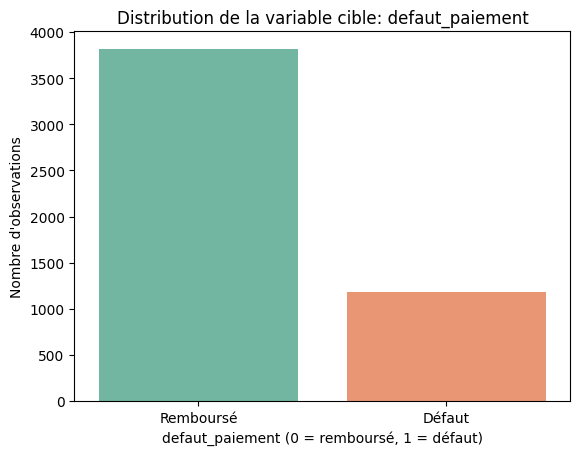

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Affichage du nombre d’occurrences pour chaque classe de la variable cible
sns.countplot(data=df, x='defaut_paiement', palette='Set2')

plt.title('Distribution de la variable cible: defaut_paiement')
plt.xlabel('defaut_paiement (0 = remboursé, 1 = défaut)')
plt.ylabel('Nombre d\'observations')
plt.xticks([0, 1], ['Remboursé', 'Défaut'])

plt.show()

**DISTRIBUTION VARIABLE NUMERIQUES**

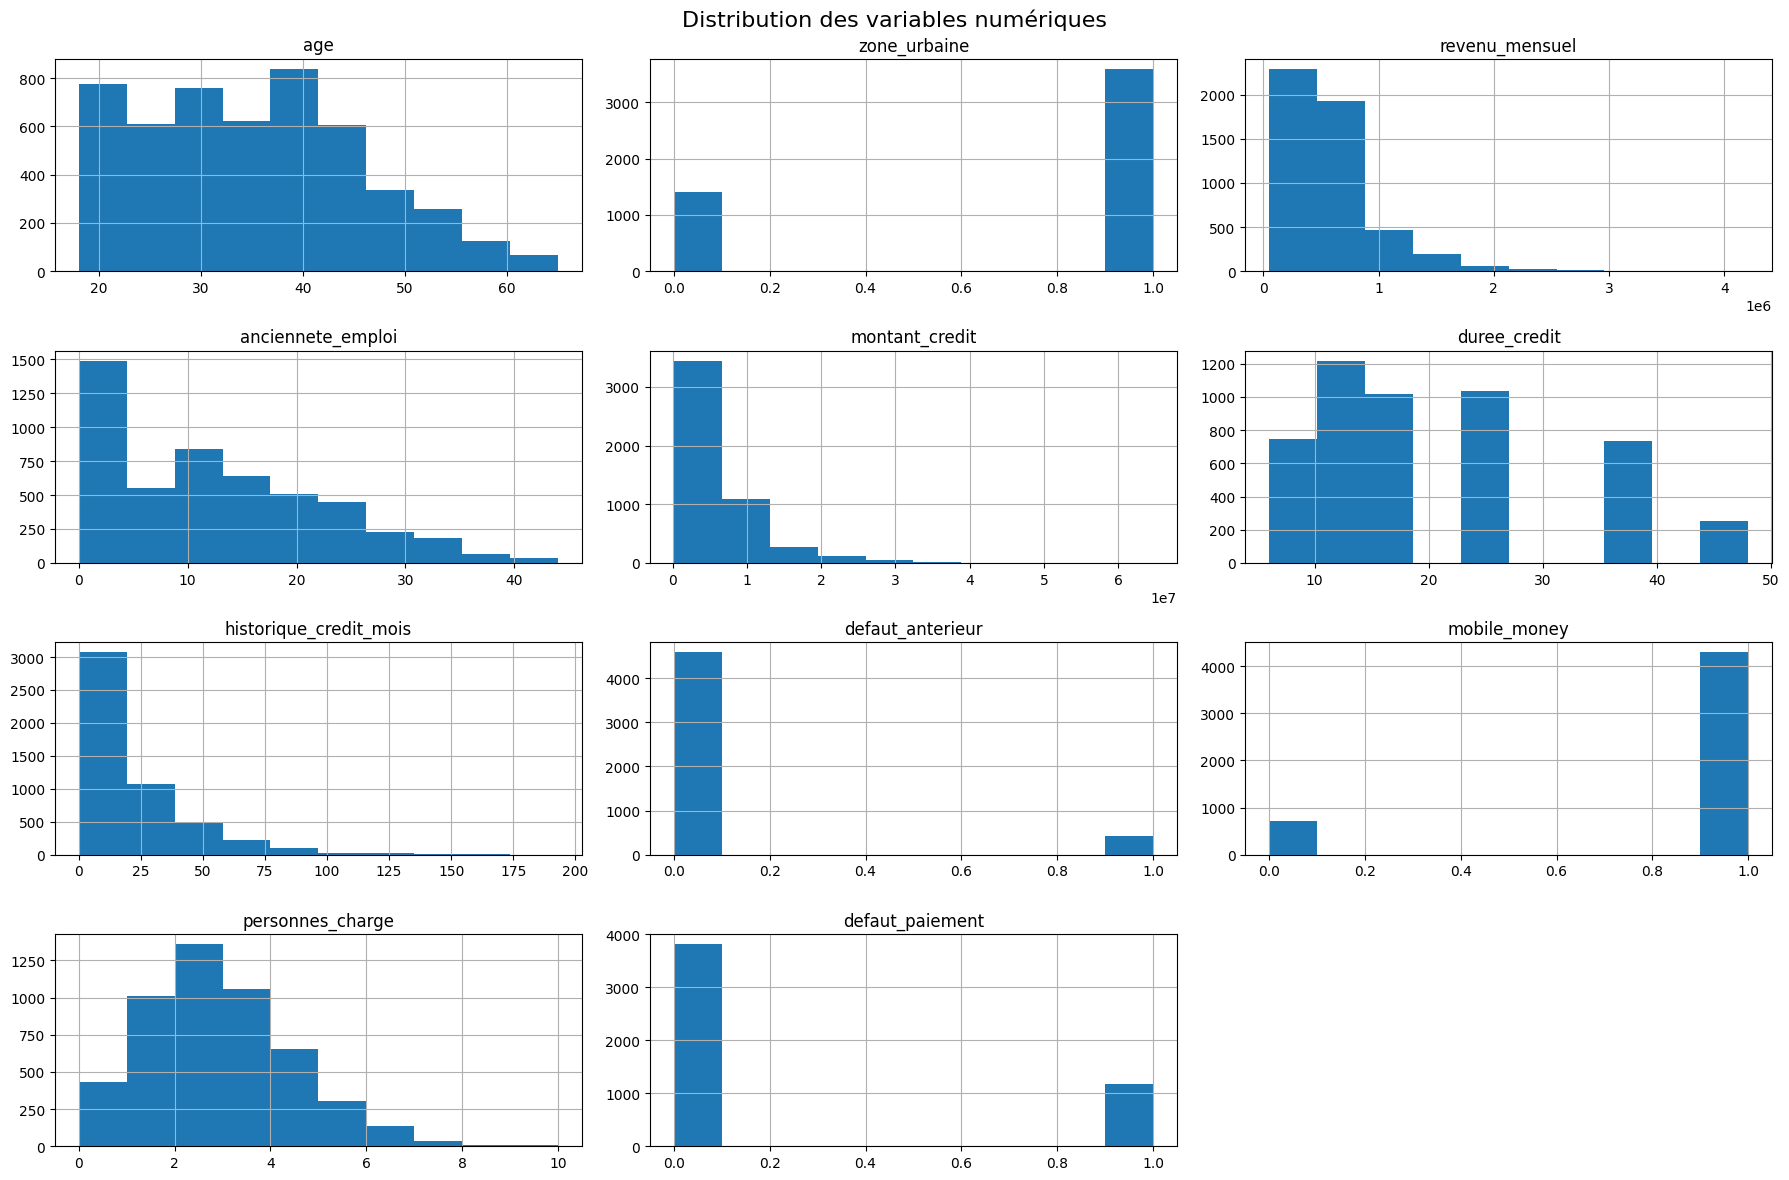

In [4]:
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(figsize=(18, 12))
plt.suptitle("Distribution des variables numériques", fontsize=16)
plt.tight_layout()
plt.show()

**DISTRIBUTION VARIABLE CATEGORIELE**

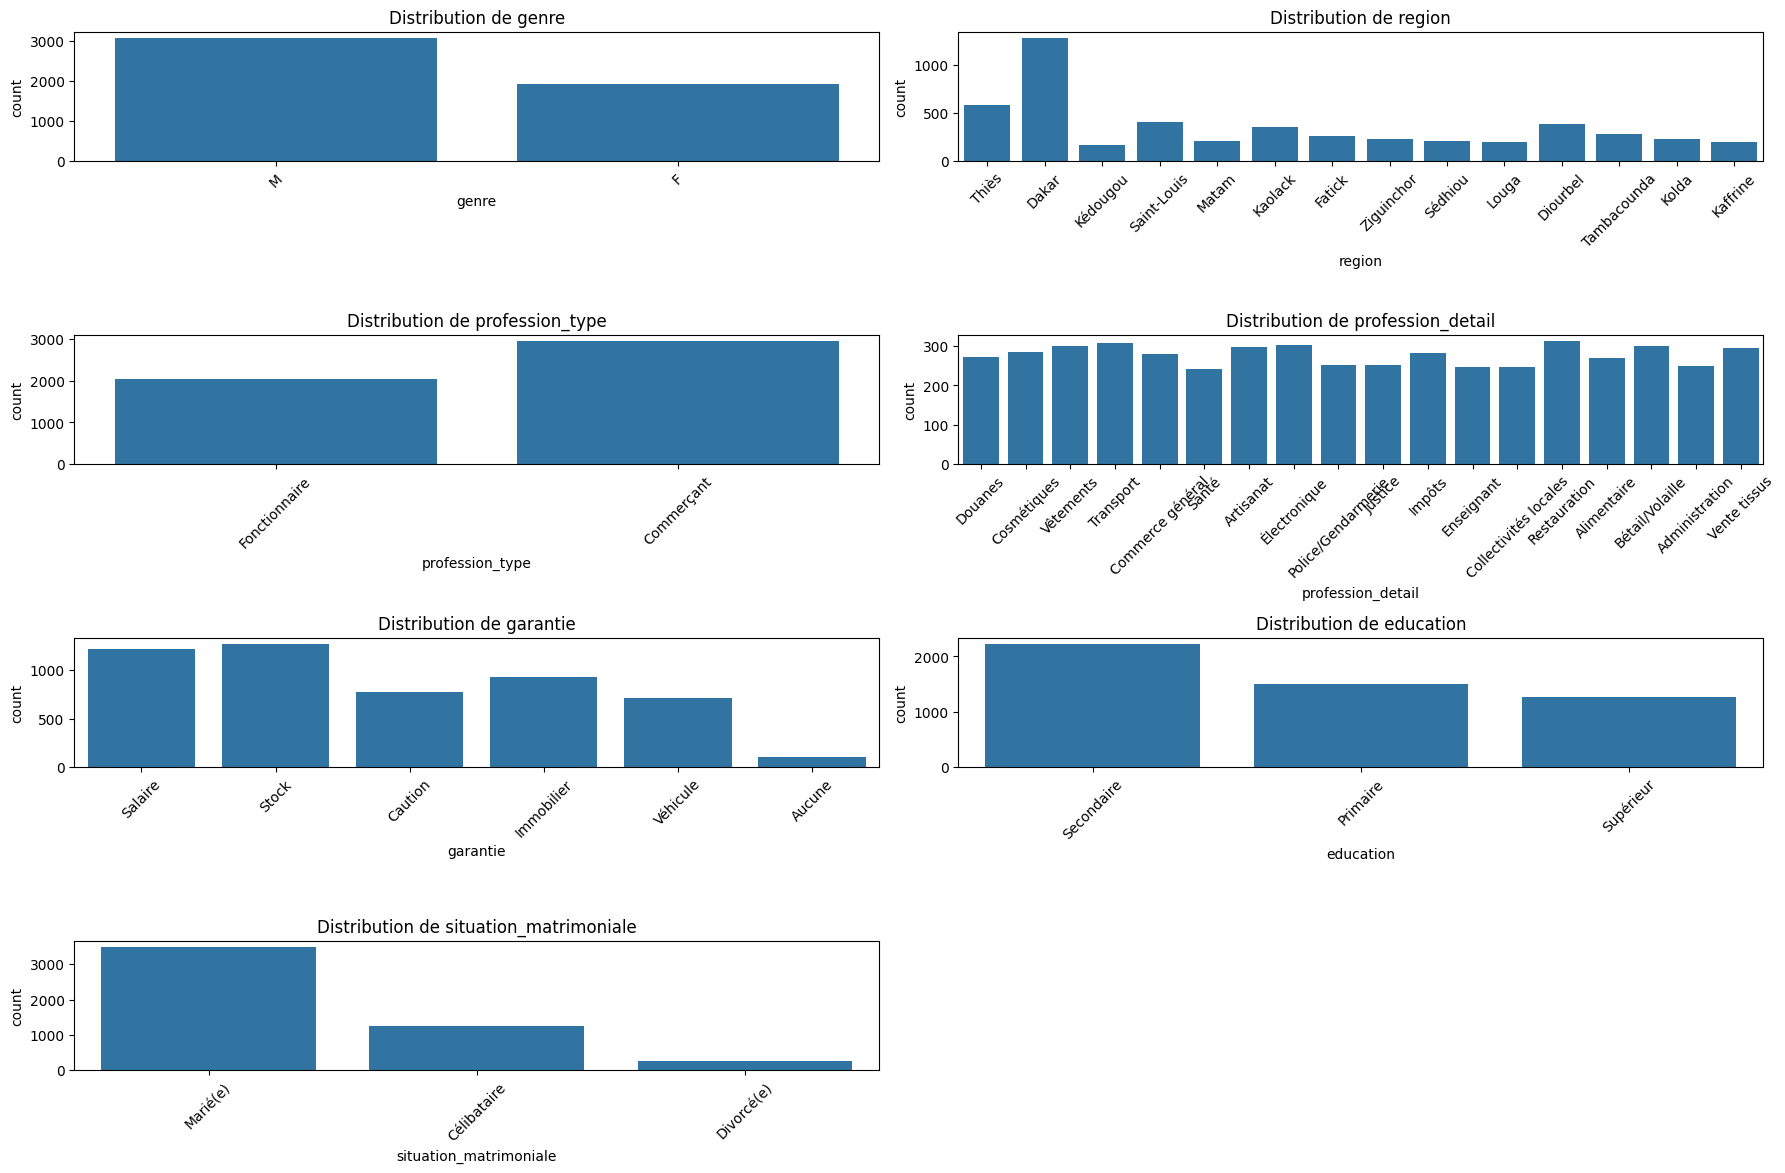

In [5]:
import seaborn as sns

categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(18, 20))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution de {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**DISTRIBUTION PAR RAPPORT AU DEFAUT DE PAIEMENT DES VARIABLES CATEGORIELLES**

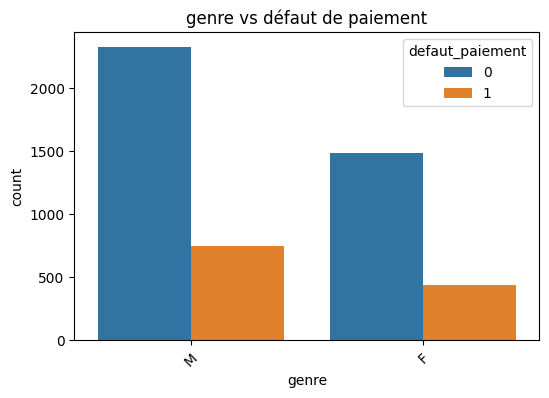

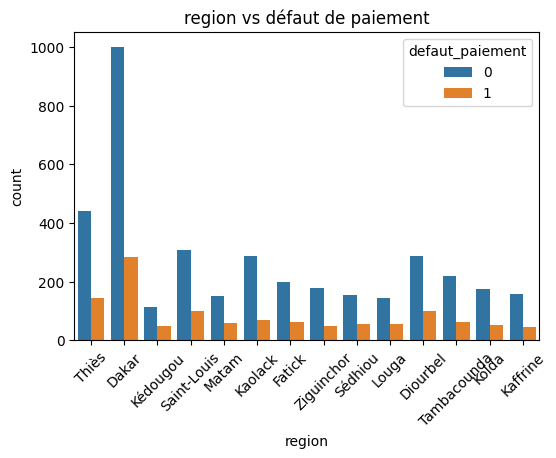

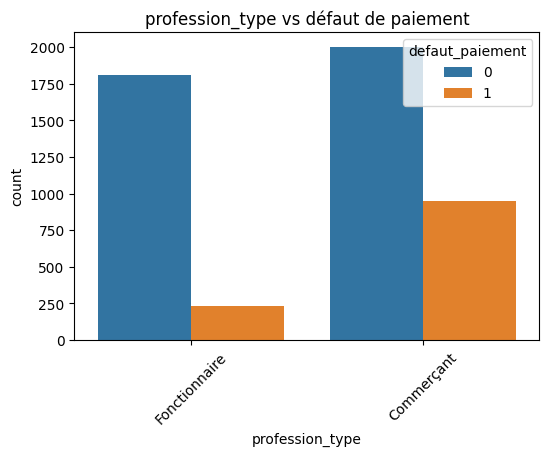

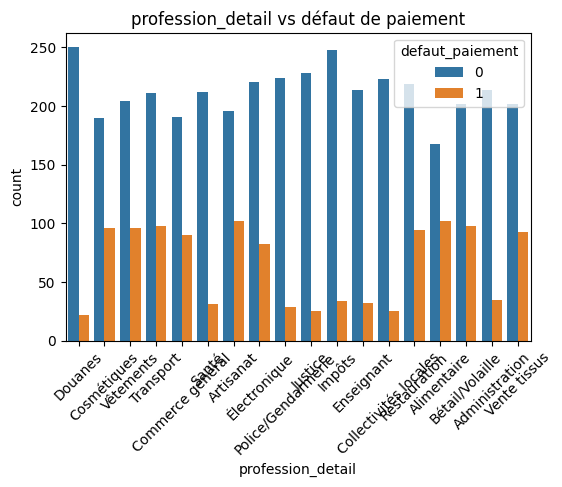

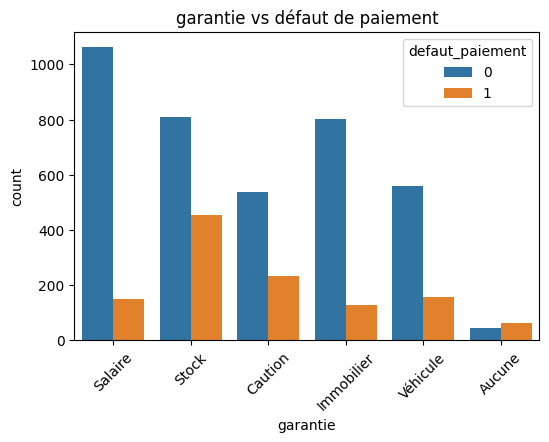

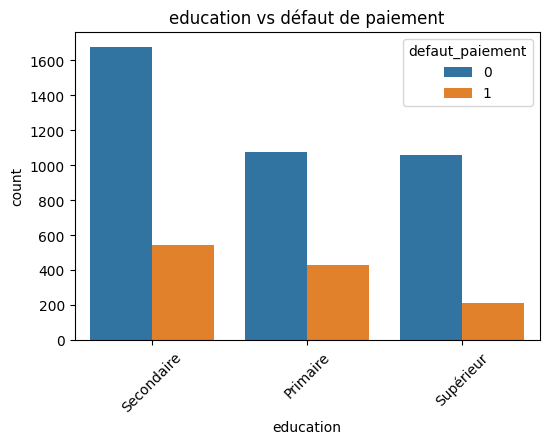

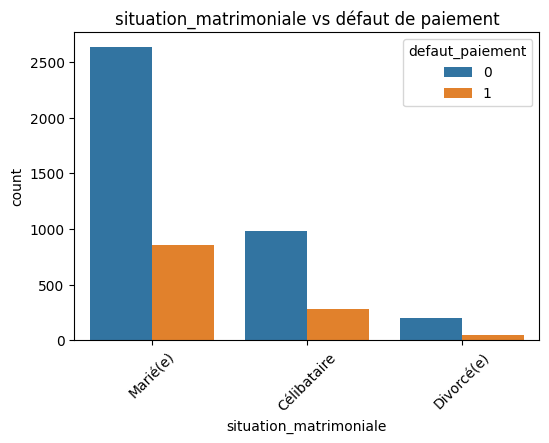

In [6]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='defaut_paiement')
    plt.title(f"{col} vs défaut de paiement")
    plt.xticks(rotation=45)
    plt.show()

**DISTRIBUTION PAR RAPPORT AU DEFAUT DE PAIEMENT DES VARIABLES NUMERIQUES**

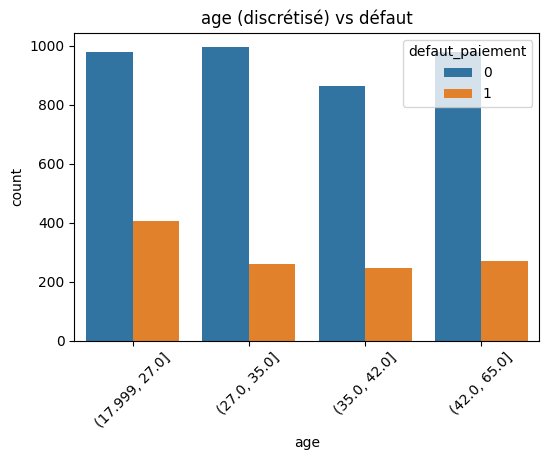

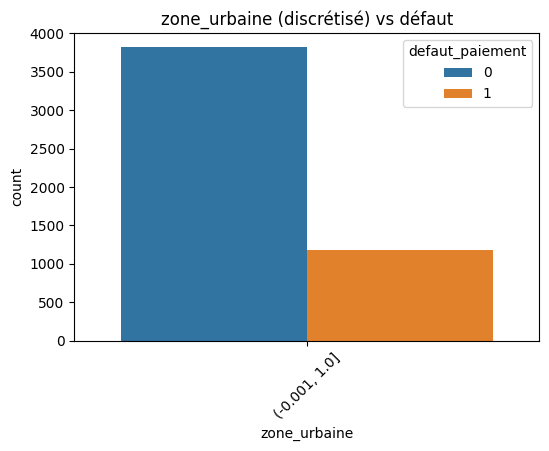

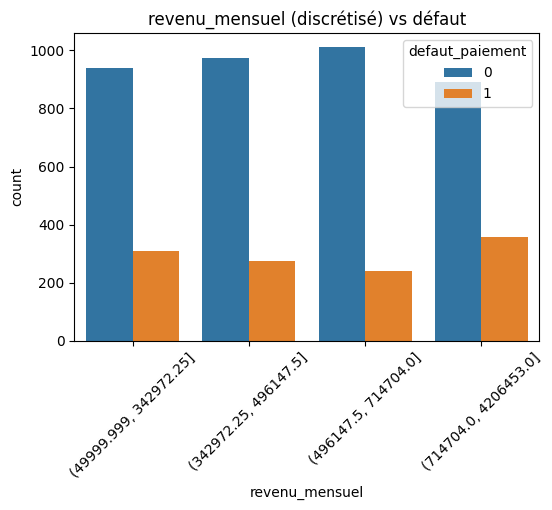

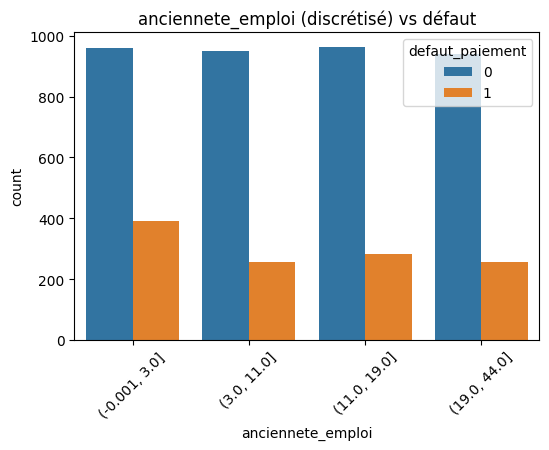

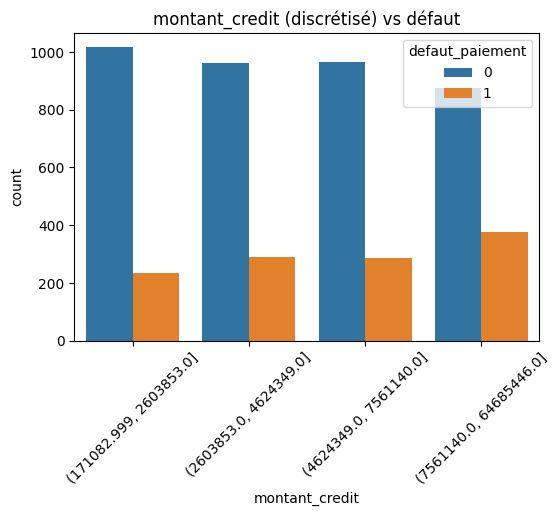

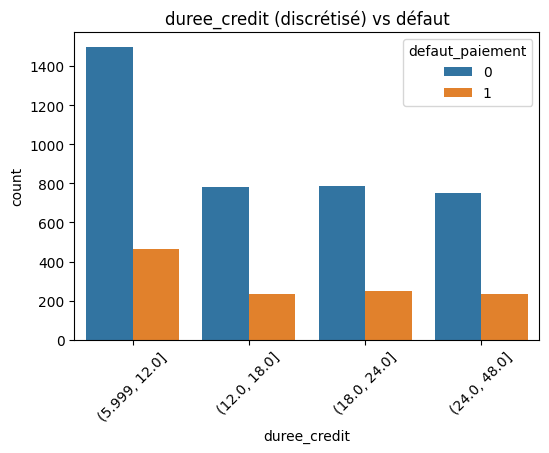

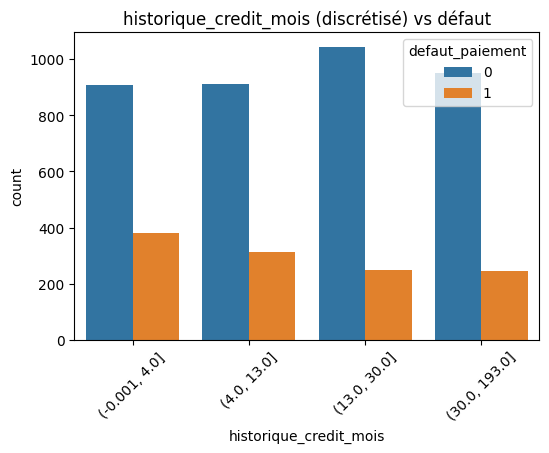

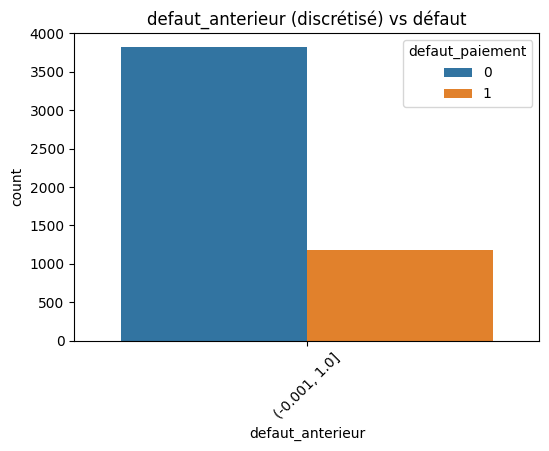

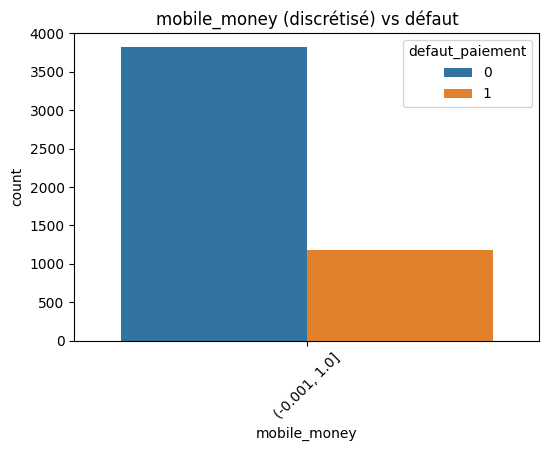

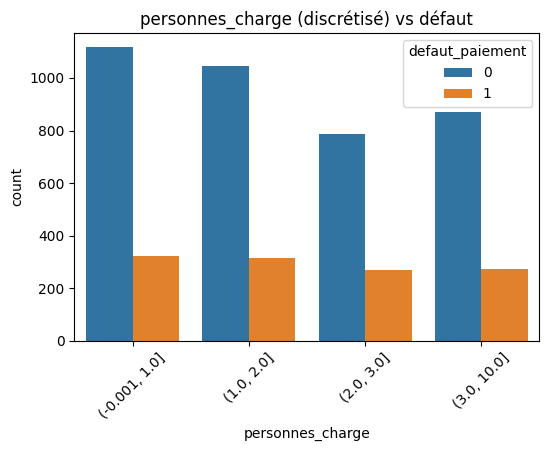

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    if col != 'defaut_paiement':
        
        bins = pd.qcut(df[col], q=4, duplicates='drop')
        
        plt.figure(figsize=(6,4))
        sns.countplot(x=bins, hue=df['defaut_paiement'])
        plt.title(f"{col} (discrétisé) vs défaut")
        plt.xticks(rotation=45)
        plt.show()

**APPERCUE DES VALEURS ABERENTES**

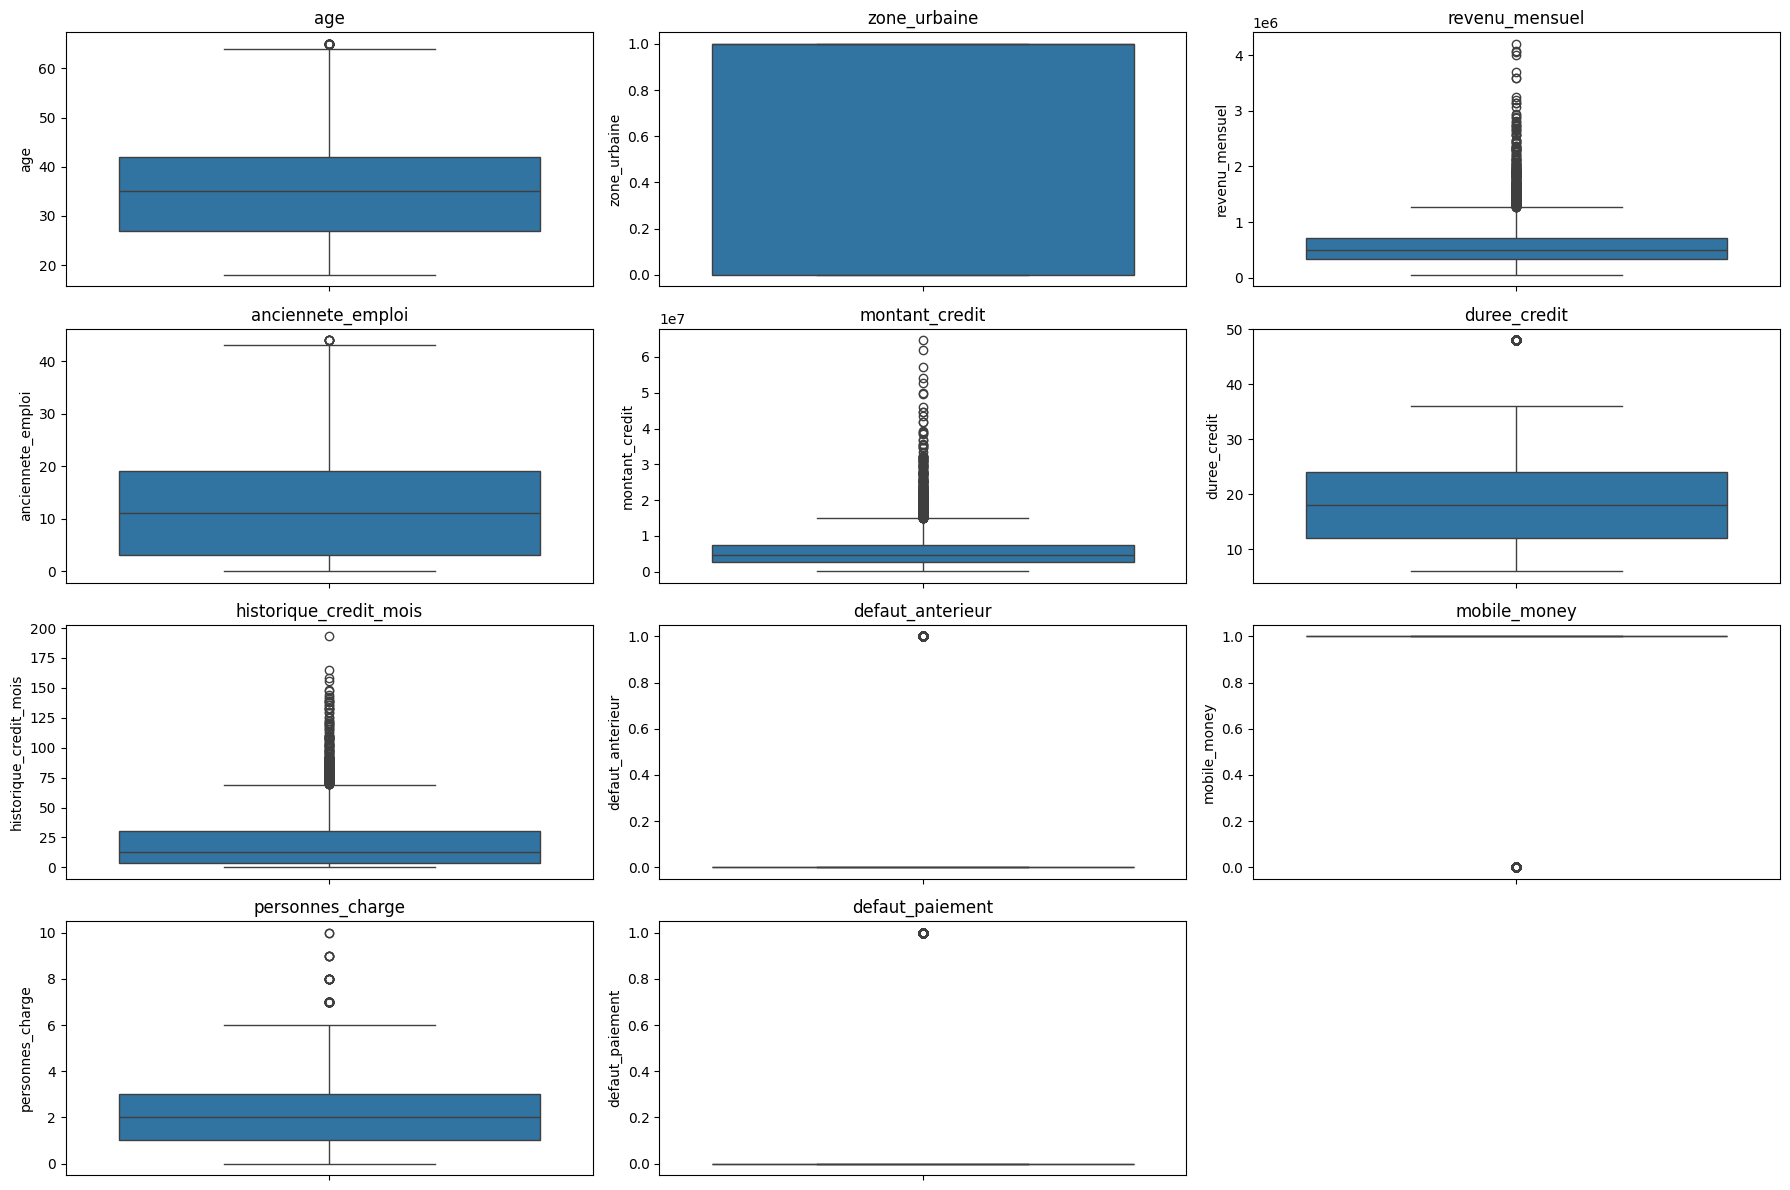

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols)//3 + 1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**MATRICE DE CORRELATION**

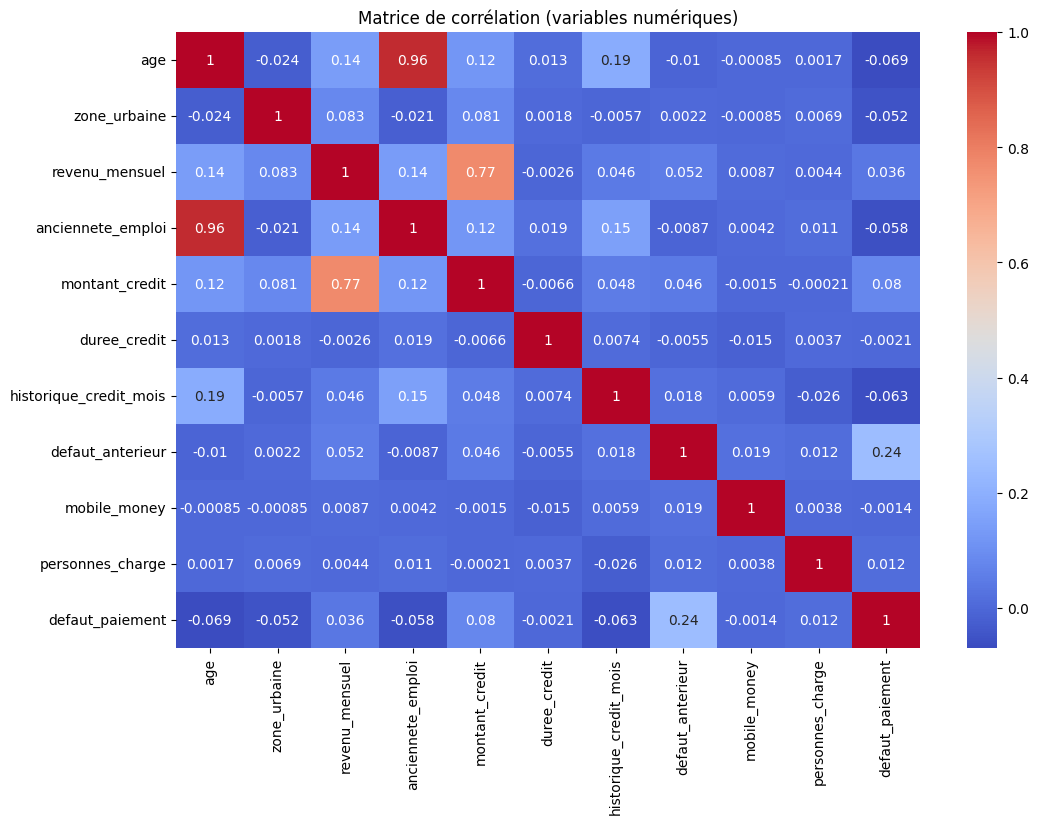

In [9]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation (variables numériques)")
plt.show()

**VARIABLE CATEGORIELLE**

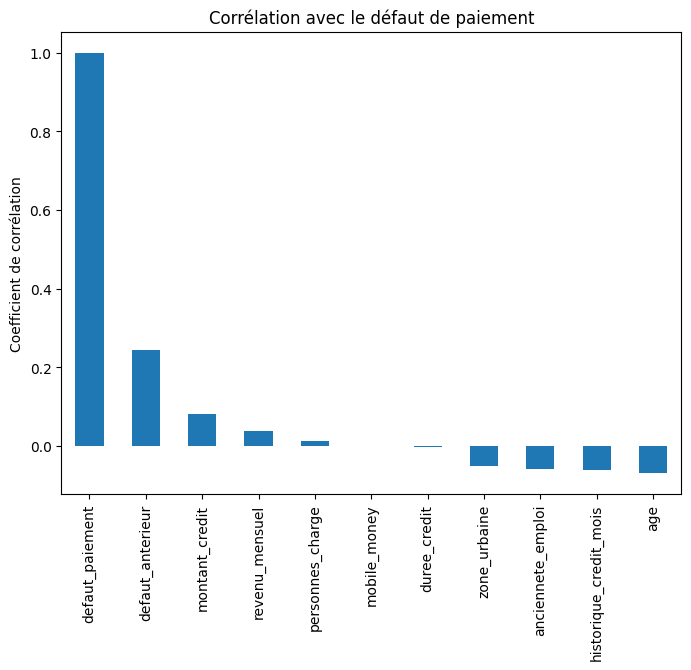

In [10]:
corr_target = corr['defaut_paiement'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr_target.plot(kind='bar')
plt.title("Corrélation avec le défaut de paiement")
plt.ylabel("Coefficient de corrélation")
plt.show()

**DEFINITION DES FEATURES ET TARGET**

In [11]:
#Features
X = df.drop('defaut_paiement', axis=1)

#Target
y = df['defaut_paiement']

**ENCODAGE DES VARIABLES CATEGORIELLES**

In [12]:
X = pd.get_dummies(X, drop_first=True)
print(X.shape)
print(y.value_counts())

(5000, 51)
defaut_paiement
0    3816
1    1184
Name: count, dtype: int64


**SEPARATION EN TEST ET TRAIN**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

**NORMALISATION DES DONNEES**

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**MODELE LOGISTIQUE REGRESSION**

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

**MODELE RANDOM FOREST**

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

**MODELE XGBOOST**

In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_log))

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

print("XGBOOST")
print(classification_report(y_test, y_pred_xgb))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.81      0.97      0.88       954
           1       0.75      0.26      0.39       296

    accuracy                           0.80      1250
   macro avg       0.78      0.62      0.64      1250
weighted avg       0.80      0.80      0.77      1250

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.80      0.98      0.88       954
           1       0.74      0.22      0.34       296

    accuracy                           0.80      1250
   macro avg       0.77      0.60      0.61      1250
weighted avg       0.79      0.80      0.75      1250

XGBOOST
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       954
           1       0.55      0.32      0.40       296

    accuracy                           0.78      1250
   macro avg       0.68      0.62      0.63      1250
weighted avg       0.75      0.7

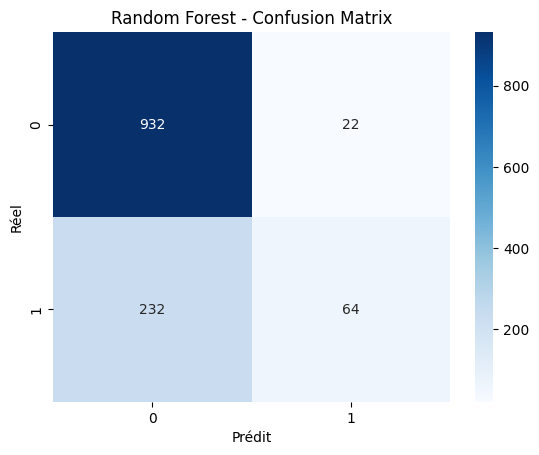

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

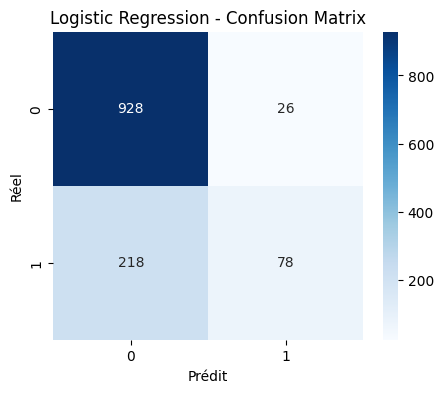

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

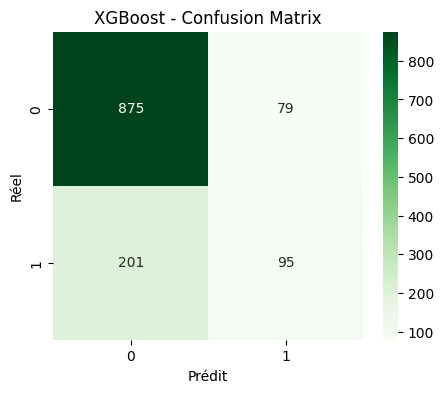

In [21]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

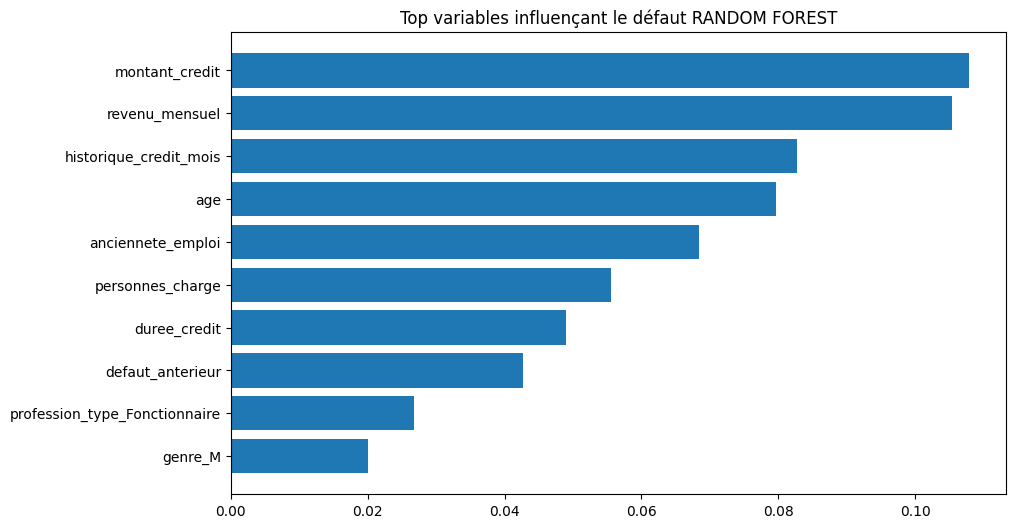

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top variables influençant le défaut RANDOM FOREST")
plt.show()

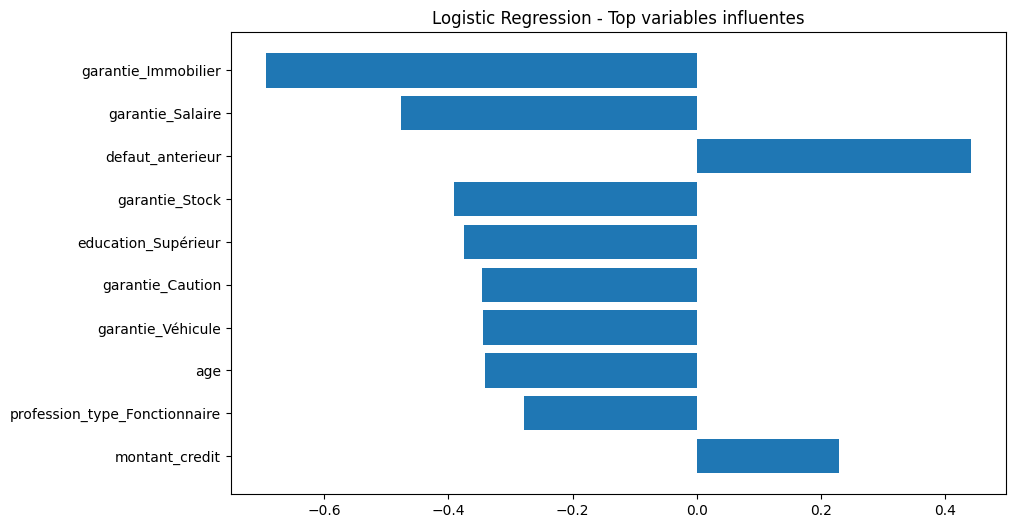

In [23]:
import pandas as pd
import numpy as np

log_importance = pd.DataFrame({
    'variable': X.columns,
    'coefficient': log_model.coef_[0]
})

log_importance['abs_coef'] = np.abs(log_importance['coefficient'])
log_importance = log_importance.sort_values('abs_coef', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(log_importance['variable'][:10], log_importance['coefficient'][:10])
plt.gca().invert_yaxis()
plt.title("Logistic Regression - Top variables influentes")
plt.show()

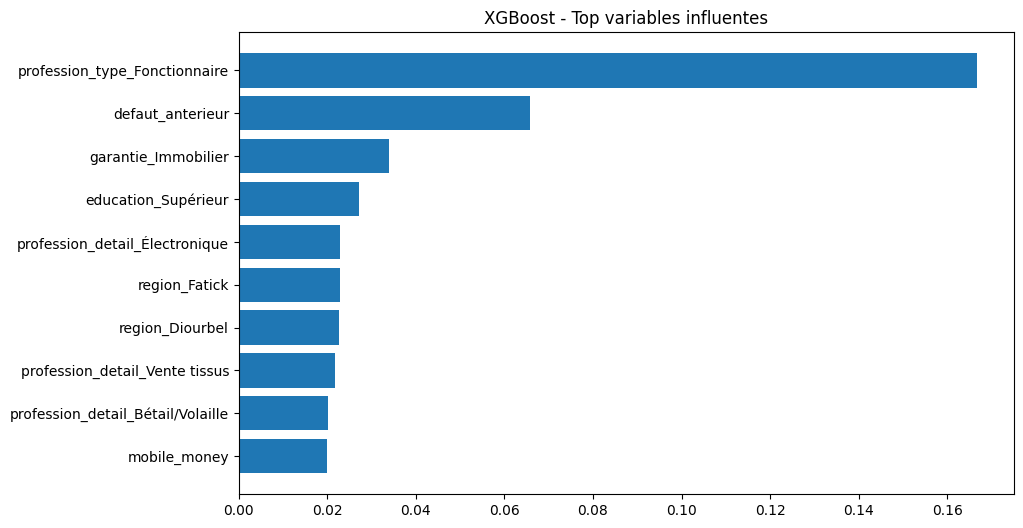

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

xgb_importance = pd.DataFrame({
    'variable': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(xgb_importance['variable'][:10], xgb_importance['importance'][:10])
plt.gca().invert_yaxis()
plt.title("XGBoost - Top variables influentes")
plt.show()

**EQUILIBRAGE DES CLASSES**

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", y_train.value_counts())
print("Après SMOTE :", y_train_smote.value_counts())

Avant SMOTE : defaut_paiement
0    2862
1     888
Name: count, dtype: int64
Après SMOTE : defaut_paiement
0    2862
1    2862
Name: count, dtype: int64


In [26]:
xgb_model = XGBClassifier(eval_metric='logloss')

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_model.predict(X_test)

In [27]:
from sklearn.metrics import classification_report


print("XGBOOST + SMOTE")
print(classification_report(y_test, y_pred_xgb_smote))

XGBOOST + SMOTE
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       954
           1       0.49      0.36      0.41       296

    accuracy                           0.76      1250
   macro avg       0.65      0.62      0.63      1250
weighted avg       0.74      0.76      0.75      1250



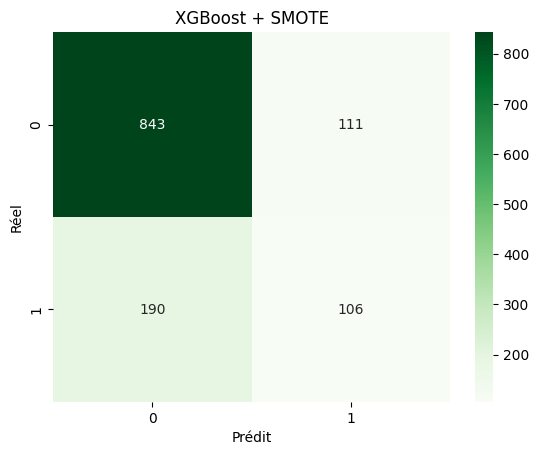

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb_smote)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost + SMOTE")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print("=== AVANT SMOTE ===")
report_before = classification_report(y_test, y_pred_xgb, output_dict=True)
print(classification_report(y_test, y_pred_xgb)) 

print("\n=== APRES SMOTE ===")
report_after = classification_report(y_test, y_pred_xgb_smote, output_dict=True)
print(classification_report(y_test, y_pred_xgb_smote))

=== AVANT SMOTE ===
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       954
           1       0.55      0.32      0.40       296

    accuracy                           0.78      1250
   macro avg       0.68      0.62      0.63      1250
weighted avg       0.75      0.78      0.75      1250


=== APRES SMOTE ===
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       954
           1       0.49      0.36      0.41       296

    accuracy                           0.76      1250
   macro avg       0.65      0.62      0.63      1250
weighted avg       0.74      0.76      0.75      1250



In [30]:
from sklearn.metrics import roc_auc_score

print("AUC avant :", roc_auc_score(y_test, y_pred_xgb))
print("AUC après :", roc_auc_score(y_test, y_pred_xgb_smote))

AUC avant : 0.6190683608136439
AUC après : 0.6208779534251233


In [31]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}



xgb = XGBClassifier(eval_metric='logloss', random_state=42)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',   # très important pour classe 1
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_smote, y_train_smote)

print("Best params:", grid.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.7}


In [32]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       954
           1       0.43      0.55      0.49       296

    accuracy                           0.72      1250
   macro avg       0.64      0.66      0.65      1250
weighted avg       0.75      0.72      0.73      1250



In [34]:
from sklearn.metrics import f1_score

best_f1 = 0
best_threshold = 0

for t in np.arange(0.1, 0.9, 0.05):
    y_pred_temp = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)

NameError: name 'y_proba' is not defined

In [35]:
y_proba = best_model.predict_proba(X_test)[:,1]

import numpy as np

seuil = 0.45  # à tester
y_pred_custom = (y_proba >= seuil).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.86      0.72      0.79       954
           1       0.41      0.62      0.50       296

    accuracy                           0.70      1250
   macro avg       0.64      0.67      0.64      1250
weighted avg       0.75      0.70      0.72      1250



In [36]:
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric='logloss'
)

In [37]:
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Prédictions train
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

print("TRAIN")
print(classification_report(y_train, y_train_pred))

print("TEST")
print(classification_report(y_test, y_test_pred))

TRAIN
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2862
           1       1.00      0.95      0.97       888

    accuracy                           0.99      3750
   macro avg       0.99      0.97      0.98      3750
weighted avg       0.99      0.99      0.99      3750

TEST
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       954
           1       0.55      0.32      0.40       296

    accuracy                           0.78      1250
   macro avg       0.68      0.62      0.63      1250
weighted avg       0.75      0.78      0.75      1250



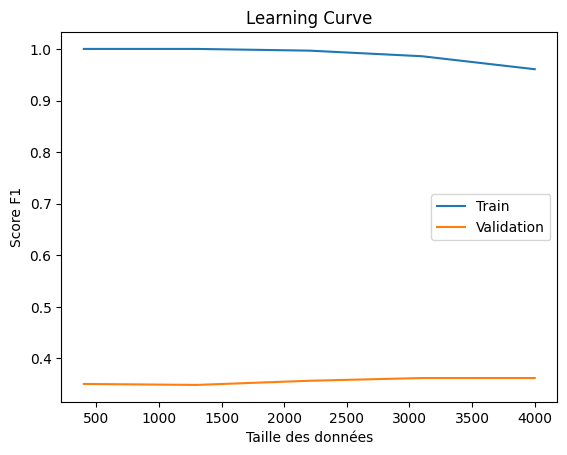

In [38]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    xgb_model, X, y, cv=5, scoring='f1'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.xlabel("Taille des données")
plt.ylabel("Score F1")
plt.show()

In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1')

print("Scores CV:", scores)
print("Moyenne:", scores.mean())

Scores CV: [0.37183099 0.39673913 0.33753149 0.37566138 0.328125  ]
Moyenne: 0.36197759563154935


In [40]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# prédictions
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

print("TRAIN")
print(classification_report(y_train, y_train_pred))

print("TEST")
print(classification_report(y_test, y_test_pred))

TRAIN
              precision    recall  f1-score   support

           0       0.83      0.98      0.90      2862
           1       0.85      0.34      0.49       888

    accuracy                           0.83      3750
   macro avg       0.84      0.66      0.69      3750
weighted avg       0.83      0.83      0.80      3750

TEST
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       954
           1       0.70      0.23      0.35       296

    accuracy                           0.79      1250
   macro avg       0.75      0.60      0.61      1250
weighted avg       0.78      0.79      0.75      1250



In [41]:
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [42]:
print("Train score:", xgb_model.score(X_train, y_train))
print("Test score:", xgb_model.score(X_test, y_test))

Train score: 0.9517333333333333
Test score: 0.7792


In [43]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.03,
    
    subsample=0.7,
    colsample_bytree=0.7,
    
    min_child_weight=5,
    
    reg_alpha=2,
    reg_lambda=5,
    
    gamma=1,
    
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
print("Train:", xgb_model.score(X_train, y_train))
print("Test:", xgb_model.score(X_test, y_test))

Train: 0.7877333333333333
Test: 0.7968


In [45]:
from sklearn.metrics import roc_auc_score

y_proba = xgb_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC :", auc)

ROC-AUC : 0.7483816363533344


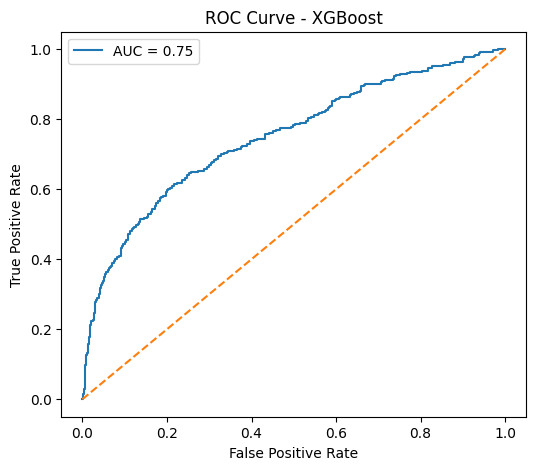

In [46]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

In [47]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=kfold,
    scoring='f1'
)

print("Scores F1 par fold :", scores)
print("F1 moyen :", scores.mean())
print("Ecart-type :", scores.std())

Scores F1 par fold : [0.27242525 0.30363036 0.26027397 0.25605536 0.28965517]
F1 moyen : 0.2764080241088142
Ecart-type : 0.01792731764780731


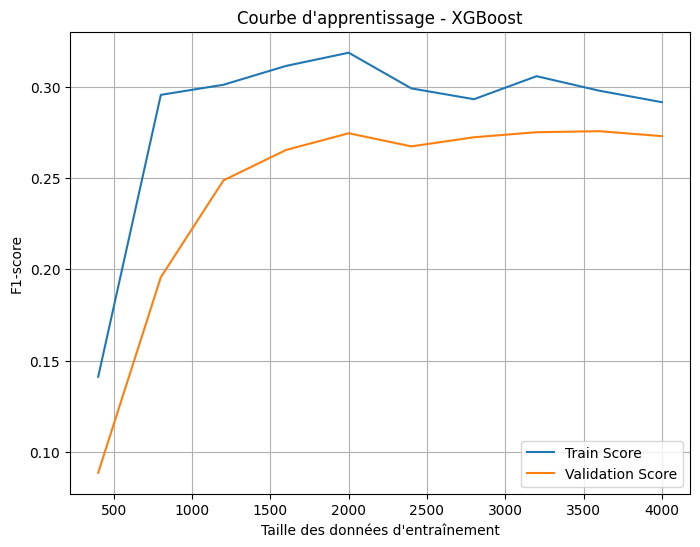

In [48]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label='Train Score')
plt.plot(train_sizes, test_mean, label='Validation Score')

plt.xlabel("Taille des données d'entraînement")
plt.ylabel("F1-score")
plt.title("Courbe d'apprentissage - XGBoost")

plt.legend()
plt.grid(True)

plt.show()

In [49]:
from sklearn.metrics import classification_report

y_pred = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.98      0.88       954
           1       0.77      0.20      0.32       296

    accuracy                           0.80      1250
   macro avg       0.78      0.59      0.60      1250
weighted avg       0.79      0.80      0.75      1250



Train score : 0.7890666666666667
Test score : 0.7984

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       954
           1       0.48      0.58      0.53       296

    accuracy                           0.75      1250
   macro avg       0.67      0.69      0.68      1250
weighted avg       0.77      0.75      0.76      1250



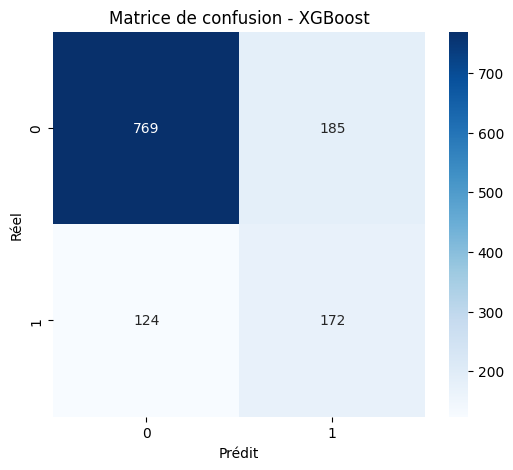


ROC-AUC : 0.7494723497081988


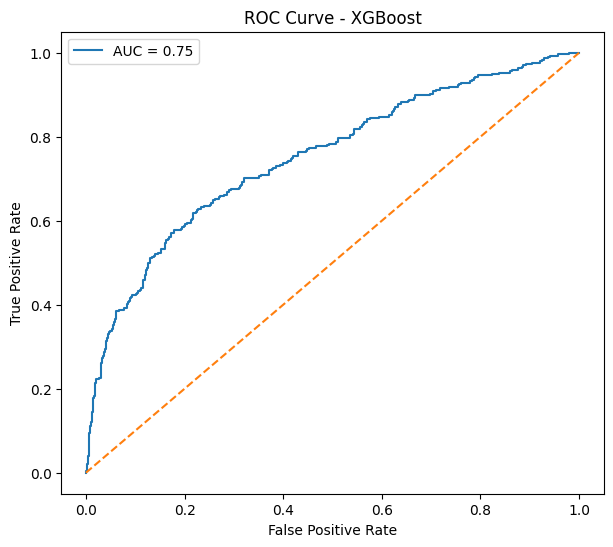

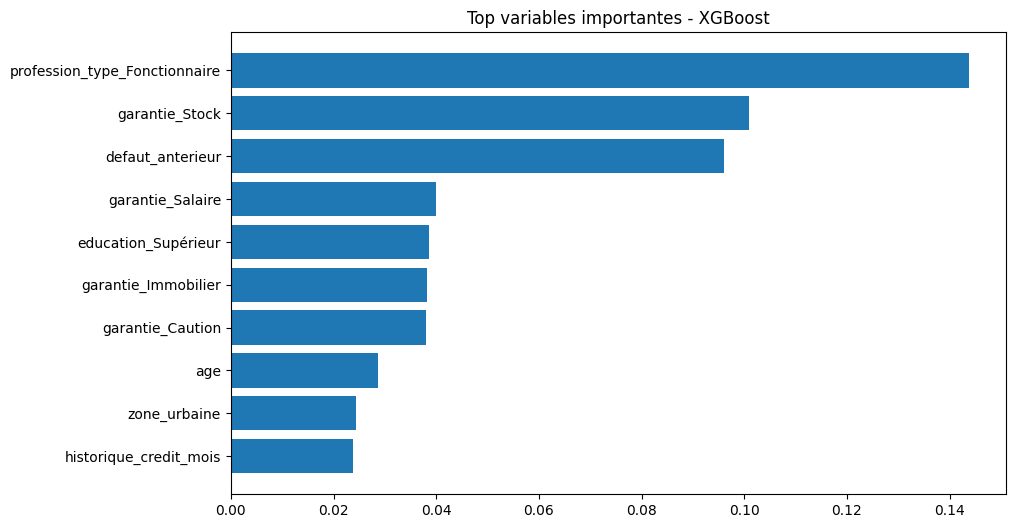


F1-score par fold : [0.28664495 0.32797428 0.30921053 0.2662116  0.31125828]
F1-score moyen : 0.30025992724488887
Ecart-type : 0.021511940805191514


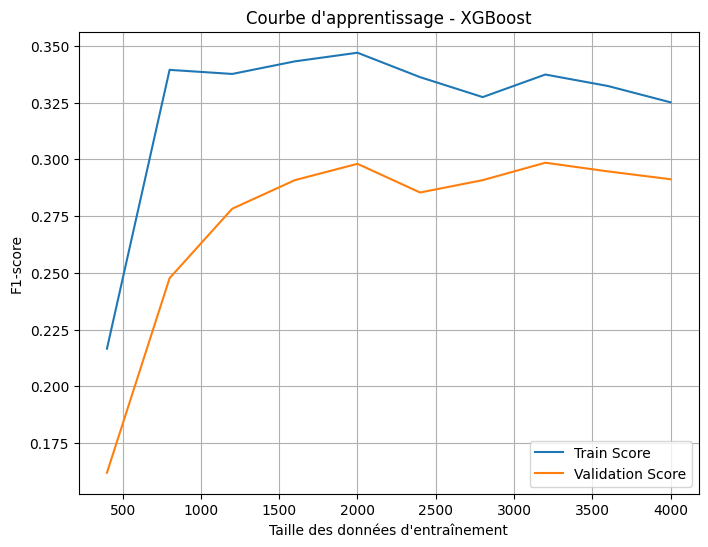

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ======================================================
# MODELE XGBOOST OPTIMISÉ CONTRE LE SURAPPRENTISSAGE
# ======================================================

xgb_model = XGBClassifier(
    
    # arbres
    n_estimators=200,
    max_depth=3,
    
    # apprentissage
    learning_rate=0.03,
    
    # anti-overfitting
    subsample=0.7,
    colsample_bytree=0.7,
    
    # régularisation
    reg_alpha=2,
    reg_lambda=5,
    
    # contrôle complexité
    gamma=1,
    min_child_weight=5,
    
    # reproductibilité
    random_state=42,
    
    # métrique
    eval_metric='logloss'
)

# ======================================================
# ENTRAINEMENT
# ======================================================

xgb_model.fit(X_train, y_train)

# ======================================================
# VERIFICATION SURAPPRENTISSAGE
# ======================================================

train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)

print("Train score :", train_score)
print("Test score :", test_score)

# ======================================================
# PREDICTIONS PROBABILITES
# ======================================================

y_proba = xgb_model.predict_proba(X_test)[:,1]

# ======================================================
# SEUIL OPTIMISÉ
# ======================================================

threshold = 0.30

y_pred = (y_proba > threshold).astype(int)

# ======================================================
# CLASSIFICATION REPORT
# ======================================================

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# ======================================================
# MATRICE DE CONFUSION
# ======================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matrice de confusion - XGBoost")
plt.xlabel("Prédit")
plt.ylabel("Réel")

plt.show()

# ======================================================
# ROC AUC
# ======================================================

auc = roc_auc_score(y_test, y_proba)

print("\nROC-AUC :", auc)

# ======================================================
# COURBE ROC
# ======================================================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

# ======================================================
# IMPORTANCE DES VARIABLES
# ======================================================

importance = xgb_model.feature_importances_

indices = np.argsort(importance)[::-1]

top_n = 10

plt.figure(figsize=(10,6))

plt.barh(
    X.columns[indices[:top_n]],
    importance[indices[:top_n]]
)

plt.gca().invert_yaxis()

plt.title("Top variables importantes - XGBoost")

plt.show()

# ======================================================
# VALIDATION CROISÉE K-FOLD
# ======================================================

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=kfold,
    scoring='f1'
)

print("\nF1-score par fold :", cv_scores)
print("F1-score moyen :", cv_scores.mean())
print("Ecart-type :", cv_scores.std())

# ======================================================
# COURBE D'APPRENTISSAGE
# ======================================================

train_sizes, train_scores, test_scores = learning_curve(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    label='Train Score'
)

plt.plot(
    train_sizes,
    test_mean,
    label='Validation Score'
)

plt.xlabel("Taille des données d'entraînement")
plt.ylabel("F1-score")

plt.title("Courbe d'apprentissage - XGBoost")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


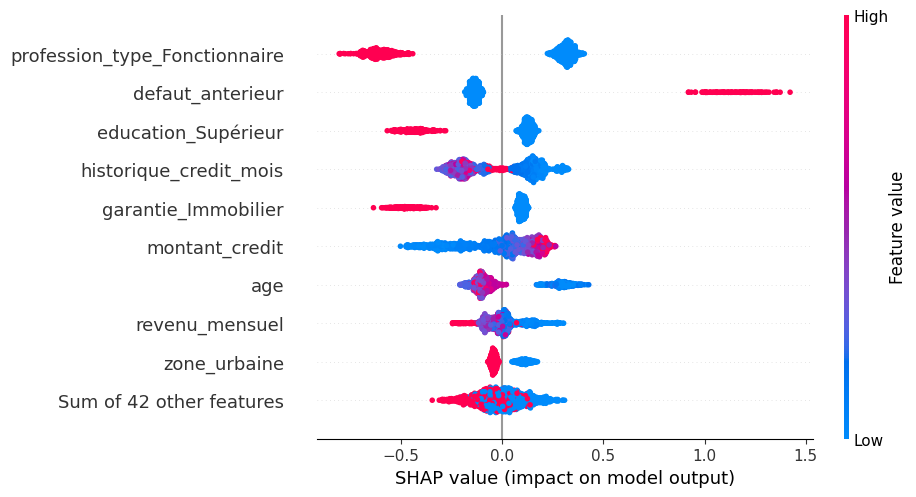

In [31]:
import shap

# explainer
explainer = shap.Explainer(xgb_model)

# calcul shap
shap_values = explainer(X_test)

# graphique global
shap.plots.beeswarm(shap_values)

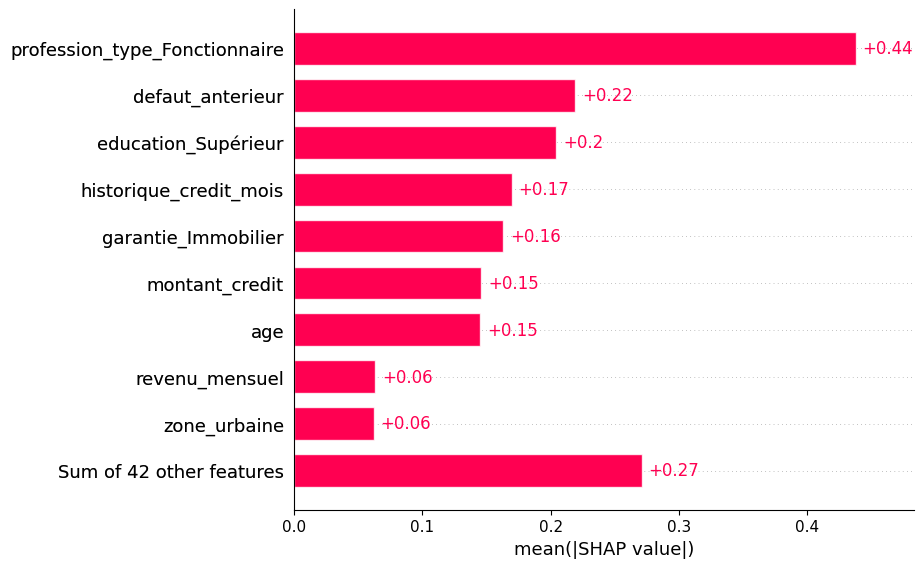

In [32]:
shap.plots.bar(shap_values)

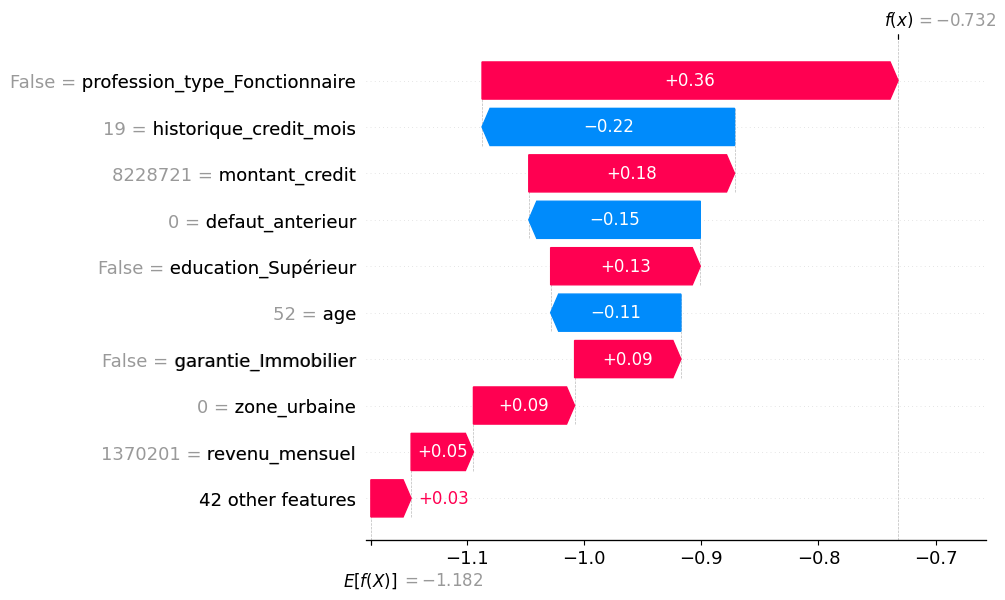

In [33]:
shap.plots.waterfall(shap_values[0])

In [34]:
proba_defaut = xgb_model.predict_proba(X_test)[:,1]

In [35]:
credit_score = (1 - proba_defaut) * 1000

In [36]:
resultats = X_test.copy()

resultats['probabilite_defaut'] = proba_defaut
resultats['credit_score'] = credit_score

print(resultats.head())

      age  zone_urbaine  revenu_mensuel  anciennete_emploi  montant_credit  \
609    52             0         1370201                 31         8228721   
4935   41             0          921068                 18        15028445   
250    19             0          365484                  1         2365720   
2062   39             1         1433731                 18        21597407   
2015   32             1         1105468                 10        15135122   

      duree_credit  historique_credit_mois  defaut_anterieur  mobile_money  \
609             36                      19                 0             0   
4935            18                      65                 0             1   
250             36                      12                 0             1   
2062            12                      24                 0             1   
2015            36                       0                 0             1   

      personnes_charge  ...  garantie_Immobilier  garantie_Sal

In [37]:
def segment_risque(score):
    
    if score >= 800:
        return "Faible risque"
    
    elif score >= 600:
        return "Risque moyen"
    
    else:
        return "Risque élevé"

resultats['segment_risque'] = resultats['credit_score'].apply(segment_risque)

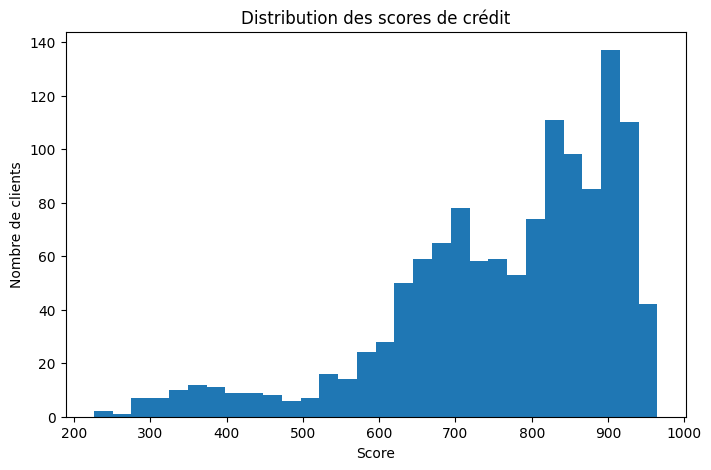

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(resultats['credit_score'], bins=30)

plt.title("Distribution des scores de crédit")

plt.xlabel("Score")
plt.ylabel("Nombre de clients")

plt.show()

In [39]:
import joblib

joblib.dump(xgb_model, "xgboost_credit_scoring.pkl")

['xgboost_credit_scoring.pkl']

In [40]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [41]:
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']